# Intelligent AOM: Realistic Thesis-Style Data Generation

This notebook creates synthetic data in a format closer to the thesis workflow: RF blueprints are generated first, a double-pass AOM-like optical spectrum is simulated, electrical pickup/background is added, and the result is background-subtracted and quantized.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

SEED = 42
QUICK_RUN = True
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True})
print('device:', DEVICE)

device: cuda


## Experiment Settings

In [2]:
DATASET_SIZE = 200 if QUICK_RUN else 10_000
RF_LIMITS = (165, 185)          # MHz, like the thesis measurement range
FREQ_COUNTS = [2, 3, 4]         # number of RF components per signal
STRENGTHS = np.array([2, 3, 4]) # relative RF amplitudes
STRENGTH_WEIGHTS = np.array([0.25, 0.15, 0.60])
PHASE_STEP = 12                 # degrees

OPTICAL_FREQS = np.arange(150, 251) # MHz, stored measured spectrum
FIBER_AOM_SHIFT = 150              # MHz; double-pass frequencies are shifted down
NOISE_LEVEL = 0.015
PICKUP_LEVEL = 0.06

info = {
    'dataset_size': DATASET_SIZE,
    'freq_count': FREQ_COUNTS,
    'freq_limits': RF_LIMITS,
    'strengths': STRENGTHS.tolist(),
    'strength_weights': STRENGTH_WEIGHTS.tolist(),
    'phases': [0, 360, PHASE_STEP],
    'preprocessing_type': 'background_subtracted_quantized_0_127',
    'note': 'Synthetic thesis-style double-pass AOM data.'
}

info

{'dataset_size': 200,
 'freq_count': [2, 3, 4],
 'freq_limits': (165, 185),
 'strengths': [2, 3, 4],
 'strength_weights': [0.25, 0.15, 0.6],
 'phases': [0, 360, 12],
 'preprocessing_type': 'background_subtracted_quantized_0_127',
 'note': 'Synthetic thesis-style double-pass AOM data.'}

## RF Blueprints

In [3]:
def make_rf_blueprint():
    n = rng.choice(FREQ_COUNTS)
    freqs = rng.choice(np.arange(RF_LIMITS[0], RF_LIMITS[1] + 1), size=n, replace=False)
    freqs.sort()
    strengths = rng.choice(STRENGTHS, size=n, p=STRENGTH_WEIGHTS)
    phases = rng.choice(np.arange(0, 360, PHASE_STEP), size=n)
    return np.column_stack([freqs, strengths, phases]).astype(np.float32)

def rf_to_fixed_vector(blueprint, max_components=4):
    x = np.zeros((max_components, 3), dtype=np.float32)
    x[:len(blueprint)] = blueprint
    x[:, 0] = (x[:, 0] - RF_LIMITS[0]) / (RF_LIMITS[1] - RF_LIMITS[0])
    x[:, 1] = x[:, 1] / STRENGTHS.max()
    x[:, 2] = x[:, 2] / 360
    return x.ravel()

example_rf = make_rf_blueprint()
example_rf

array([[178.,   4.,  72.],
       [180.,   4.,  24.]], dtype=float32)

## Double-Pass Spectrum Simulator

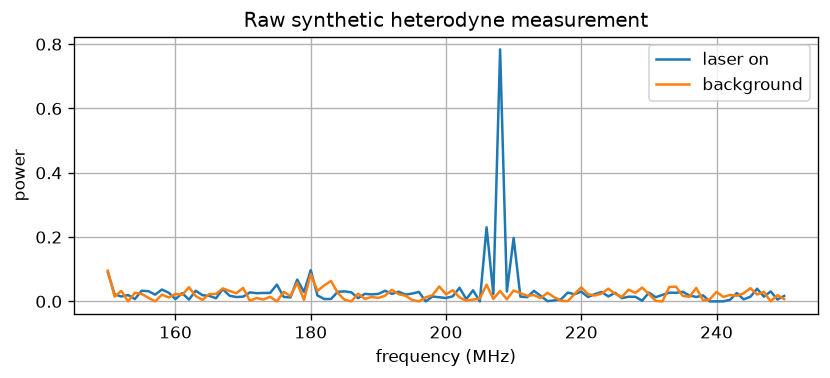

In [4]:
def diffraction_efficiency(freq_mhz):
    center = 175
    width = 11
    return np.exp(-0.5 * ((freq_mhz - center) / width) ** 2)

def add_peak(spectrum, freq_mhz, value):
    idx = int(round(freq_mhz - OPTICAL_FREQS[0]))
    if 0 <= idx < len(spectrum):
        spectrum[idx] += value

def ideal_double_pass_spectrum(blueprint):
    complex_spectrum = np.zeros(len(OPTICAL_FREQS), dtype=np.complex64)
    freqs, strengths, phases_deg = blueprint.T
    amps = strengths / np.linalg.norm(strengths)
    phases = np.deg2rad(phases_deg)

    for i in range(len(freqs)):
        for j in range(len(freqs)):
            optical_freq = freqs[i] + freqs[j] - FIBER_AOM_SHIFT
            efficiency = diffraction_efficiency(freqs[i]) * diffraction_efficiency(freqs[j])
            path_phase = phases[i] + phases[j]
            value = amps[i] * amps[j] * efficiency * np.exp(1j * path_phase)
            add_peak(complex_spectrum, optical_freq, value)

    return np.abs(complex_spectrum) ** 2

def electrical_pickup(blueprint):
    pickup = np.zeros(len(OPTICAL_FREQS), dtype=np.float32)
    for freq in blueprint[:, 0]:
        add_peak(pickup, freq, PICKUP_LEVEL)
    add_peak(pickup, 150, PICKUP_LEVEL * 1.5)
    return pickup

def measure_spectrum(blueprint, laser_on=True):
    background = 0.02 + electrical_pickup(blueprint)
    noise = rng.normal(0, NOISE_LEVEL, size=len(OPTICAL_FREQS))
    signal = ideal_double_pass_spectrum(blueprint) if laser_on else 0
    return np.clip(background + signal + noise, 0, None).astype(np.float32)

raw_signal = measure_spectrum(example_rf, laser_on=True)
raw_background = measure_spectrum(example_rf, laser_on=False)

plt.figure(figsize=(8, 3))
plt.plot(OPTICAL_FREQS, raw_signal, label='laser on')
plt.plot(OPTICAL_FREQS, raw_background, label='background')
plt.title('Raw synthetic heterodyne measurement')
plt.xlabel('frequency (MHz)')
plt.ylabel('power')
plt.legend()
plt.show()

## Thesis-Style Preprocessing

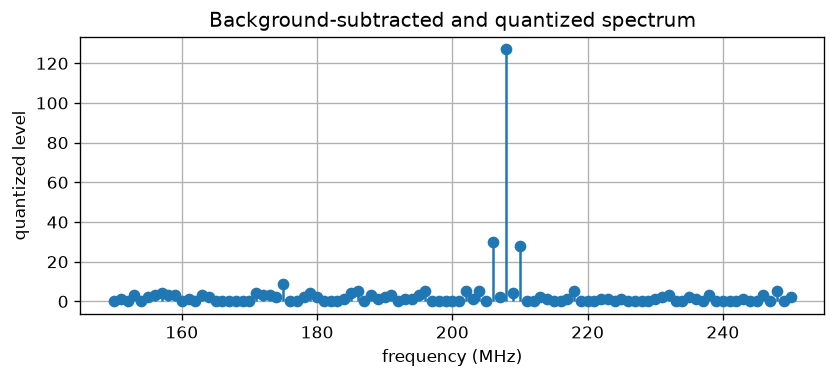

In [5]:
def quantize_0_127(spectrum):
    spectrum = np.clip(spectrum, 0, None)
    lo, hi = spectrum.min(), spectrum.max()
    if hi <= lo:
        return np.zeros_like(spectrum, dtype=np.uint8)
    return np.rint(127 * (spectrum - lo) / (hi - lo)).astype(np.uint8)

def preprocess(signal, background):
    cleaned = np.clip(signal - background, 0, None)
    return quantize_0_127(cleaned)

processed = preprocess(raw_signal, raw_background)

plt.figure(figsize=(8, 3))
plt.stem(OPTICAL_FREQS, processed, basefmt=' ')
plt.title('Background-subtracted and quantized spectrum')
plt.xlabel('frequency (MHz)')
plt.ylabel('quantized level')
plt.show()

## Build Dataset

In [6]:
def make_data_point():
    blueprint = make_rf_blueprint()
    signal = measure_spectrum(blueprint, laser_on=True)
    background = measure_spectrum(blueprint, laser_on=False)
    spectrum = preprocess(signal, background)
    return blueprint, rf_to_fixed_vector(blueprint), spectrum

def make_dataset(n):
    blueprints, X, y = [], [], []
    for _ in range(n):
        blueprint, rf_vector, spectrum = make_data_point()
        blueprints.append(blueprint)
        X.append(rf_vector)
        y.append(spectrum)
    return blueprints, np.array(X, dtype=np.float32), np.array(y, dtype=np.uint8)

blueprints, rf_vectors, spectra = make_dataset(DATASET_SIZE)
rf_vectors.shape, spectra.shape, spectra.dtype

((200, 12), (200, 101), dtype('uint8'))

## Inspect Generated Samples

RF blueprint columns: frequency MHz, relative strength, phase deg
[[168.   4.  24.]
 [172.   2. 132.]
 [175.   2. 348.]
 [183.   4. 108.]]


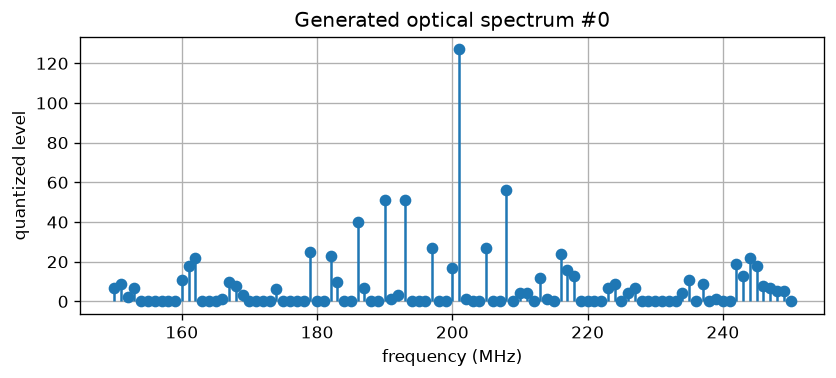

In [7]:
def plot_sample(index):
    print('RF blueprint columns: frequency MHz, relative strength, phase deg')
    print(blueprints[index])
    plt.figure(figsize=(8, 3))
    plt.stem(OPTICAL_FREQS, spectra[index], basefmt=' ')
    plt.title(f'Generated optical spectrum #{index}')
    plt.xlabel('frequency (MHz)')
    plt.ylabel('quantized level')
    plt.show()

plot_sample(0)

## Neural Network Training

The network learns the forward experimental mapping: RF blueprint -> processed optical spectrum.

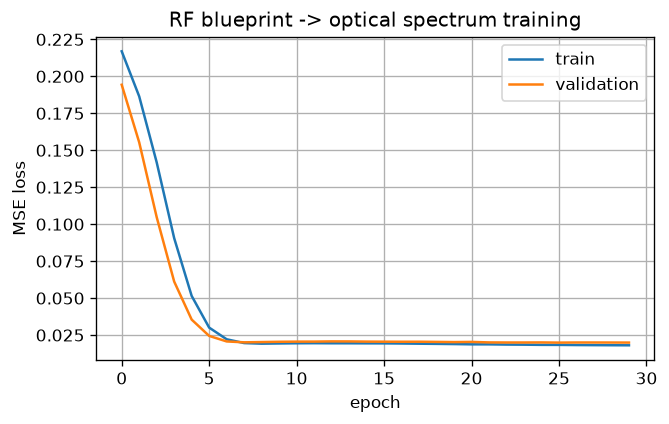

In [8]:
def build_model(input_dim=12, output_dim=101, hidden=(128, 256, 128)):
    layers = []
    last = input_dim
    for width in hidden:
        layers += [nn.Linear(last, width), nn.ReLU()]
        last = width
    layers += [nn.Linear(last, output_dim), nn.Sigmoid()]
    return nn.Sequential(*layers)

def train_model(X, y, epochs=40, batch_size=64, lr=1e-3):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32) / 127.0
    data = TensorDataset(X_tensor, y_tensor)
    n_val = max(1, len(data) // 5)
    train_ds, val_ds = random_split(data, [len(data) - n_val, n_val], generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    model = build_model(input_dim=X.shape[1], output_dim=y.shape[1]).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train': [], 'val': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(xb)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(xb), yb).item() * len(xb)

        history['train'].append(train_loss / len(train_ds))
        history['val'].append(val_loss / len(val_ds))

    return model, history

def predict_spectrum(model, rf_vector):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(rf_vector[None, :], dtype=torch.float32, device=DEVICE)
        pred = model(x).cpu().numpy()[0]
    return np.rint(127 * pred).clip(0, 127).astype(np.uint8)

model, history = train_model(rf_vectors, spectra, epochs=30 if QUICK_RUN else 100)

plt.figure(figsize=(6, 3.5))
plt.plot(history['train'], label='train')
plt.plot(history['val'], label='validation')
plt.title('RF blueprint -> optical spectrum training')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.show()

## Prediction Check

RF blueprint columns: frequency MHz, relative strength, phase deg
[[168.   4.  24.]
 [172.   2. 132.]
 [175.   2. 348.]
 [183.   4. 108.]]


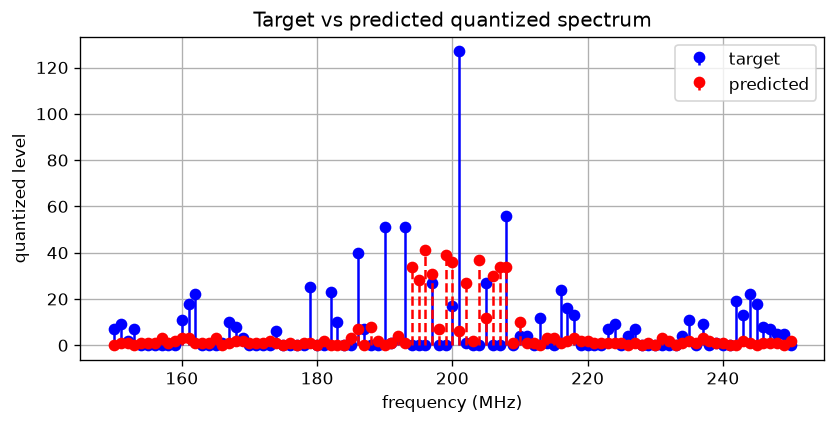

In [9]:
sample_index = 0
predicted = predict_spectrum(model, rf_vectors[sample_index])

print('RF blueprint columns: frequency MHz, relative strength, phase deg')
print(blueprints[sample_index])

plt.figure(figsize=(8, 3.5))
plt.stem(OPTICAL_FREQS, spectra[sample_index], linefmt='b-', markerfmt='bo', basefmt=' ', label='target')
plt.stem(OPTICAL_FREQS, predicted, linefmt='r--', markerfmt='ro', basefmt=' ', label='predicted')
plt.title('Target vs predicted quantized spectrum')
plt.xlabel('frequency (MHz)')
plt.ylabel('quantized level')
plt.legend()
plt.show()

## Save Dataset

In [10]:
output_dir = Path('generated_data/thesis_style')
output_dir.mkdir(parents=True, exist_ok=True)

np.save(output_dir / 'rf_vectors.npy', rf_vectors)
np.save(output_dir / 'spectra_quantized.npy', spectra)
np.save(output_dir / 'rf_blueprints.npy', np.array(blueprints, dtype=object), allow_pickle=True)
(output_dir / 'info.json').write_text(json.dumps(info, indent=2), encoding='utf-8')

if 'model' in globals():
    torch.save(model.state_dict(), output_dir / 'spectrum_model.pt')
if 'history' in globals():
    (output_dir / 'training_history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')

print('saved to', output_dir.resolve())

saved to C:\Users\anma10\PycharmProjects\intelligent-aom\generated_data\thesis_style
